# Irrigation decisions, and what a wrong one costs

**What this notebook answers:** given that we can estimate soil moisture, how
should that turn into a decision - and which method actually costs least to
run?

The previous notebook ended on an uncomfortable note: two reasonable accuracy
measures picked different winners. This notebook resolves that by asking the
only question a client actually cares about.

> Not "which model predicts best", but **"which model costs least to operate"**.

## Why accuracy is the wrong target

Irrigation errors are not symmetric.

**Applying 5 mm too much** wastes desalinated water and washes nutrients below
the roots. In the UAE that is genuinely expensive - but it is recoverable, and
the crop is unharmed.

**Applying 5 mm too little**, in a July where demand is 8.5 mm/day on sand that
holds only 35 mm in total, pushes the plant past its stress threshold within a
day. Growth stops. Severe stress is not recoverable at all.

RMSE weights those two identically. The field does not. So the evaluation here
is in dirhams.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from irrigation.viz import apply_style, colour_for, dashes_for, marker_for

apply_style()

from irrigation.decision.policy import CostModel
from irrigation.models.evaluate import render_table, run_comparison
from irrigation.physics.crop import CROPS, SOILS

crop, soil = CROPS["turfgrass"], SOILS["sand"]
results = run_comparison(crop, soil, root_depth_m=0.5, kc=0.85)

print(render_table(results))


Predictor                     Cost AED  Water mm  Events  Stress d  Severe d  Drain mm  RMSE mm  Bias mm
--------------------------------------------------------------------------------------------------------
Physics (FAO-56 balance)          2645       926     114         5         0         9     2.49    -1.47  <-- best
Sensor only                      20062       865      87        99         1         1    12.28   -10.27
Physics + sensor fusion          16533       900     112        97         0         4     9.96    -9.25
Random forest                     3055      1150     120         0         0       209     1.89     1.68
Gradient boosting                 3064      1154     120         0         0       212     1.93     1.70
XGBoost                           3036      1143     119         0         0       202     1.88     1.65


Six ways of deciding when to irrigate, run over the same simulated 120-day
Dubai summer:

- **Physics** - the FAO-56 water balance. Track what goes in and what leaves.
  No sensor, no training data, no machine learning. This is what irrigation
  scheduling has used since 1998.
- **Sensor only** - trust the probe. This is what most commercial "smart
  irrigation" does.
- **Physics + sensor fusion** - the engineer's answer: use the balance for the
  trend and let the probe correct it slowly.
- **Random forest, gradient boosting, XGBoost** - supervised models trained on
  simulated seasons, given the same information plus lagged history.


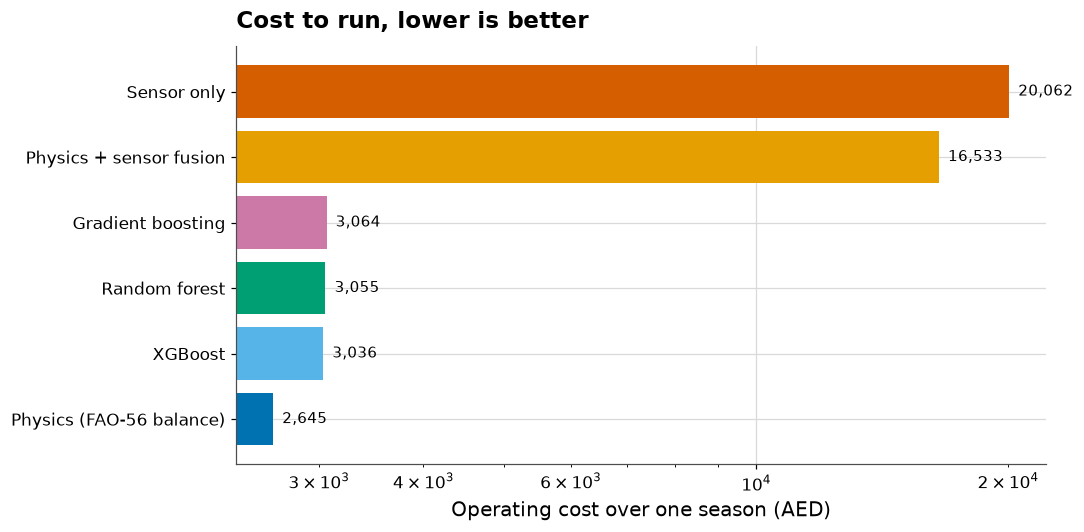

In [2]:
names: list[str] = [r.predictor_name for r in results]
costs: list[float] = [float(r.total_cost) for r in results]
rmse: list[float] = [float(r.depletion_rmse) for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
# Plain lists throughout: these values are only ranked, indexed and formatted,
# none of which needs an array, and numpy scalars reaching an f-string are
# what make `{value:,.0f}` unverifiable.
order = sorted(range(len(costs)), key=lambda i: costs[i])
positions = range(len(results))
ranked = [costs[i] for i in order]

bars = ax.barh(positions, ranked, color=[colour_for(names[i]) for i in order])
ax.set_yticks(positions, [names[i] for i in order])
ax.set_xlabel("Operating cost over one season (AED)")
ax.set_xscale("log")
ax.set_title("Cost to run, lower is better")
ax.grid(axis="x")

for index, value in enumerate(ranked):
    ax.annotate(f"{value:,.0f}", (value, index), va="center",
                xytext=(6, 0), textcoords="offset points", fontsize=10)

plt.tight_layout()
plt.show()


The scale is logarithmic because the spread is enormous. Trusting the sensor
costs roughly **eight times** what the 1998 water balance costs.

That is the single most commercially relevant number in this project, so it is
worth being precise about the cause. The simulated probe carries the failure
modes that actually break field deployments: an uncalibrated offset, and
salinity drift - Gulf irrigation water is desalinated or brackish, salts
accumulate in the root zone, and a capacitance probe reads dissolved salt as
moisture. It therefore reads **progressively wetter than reality**, so a
controller that believes it waters progressively less. The crop starves while
the dashboard shows green.

Naive fusion inherits the same bias and barely improves on it.


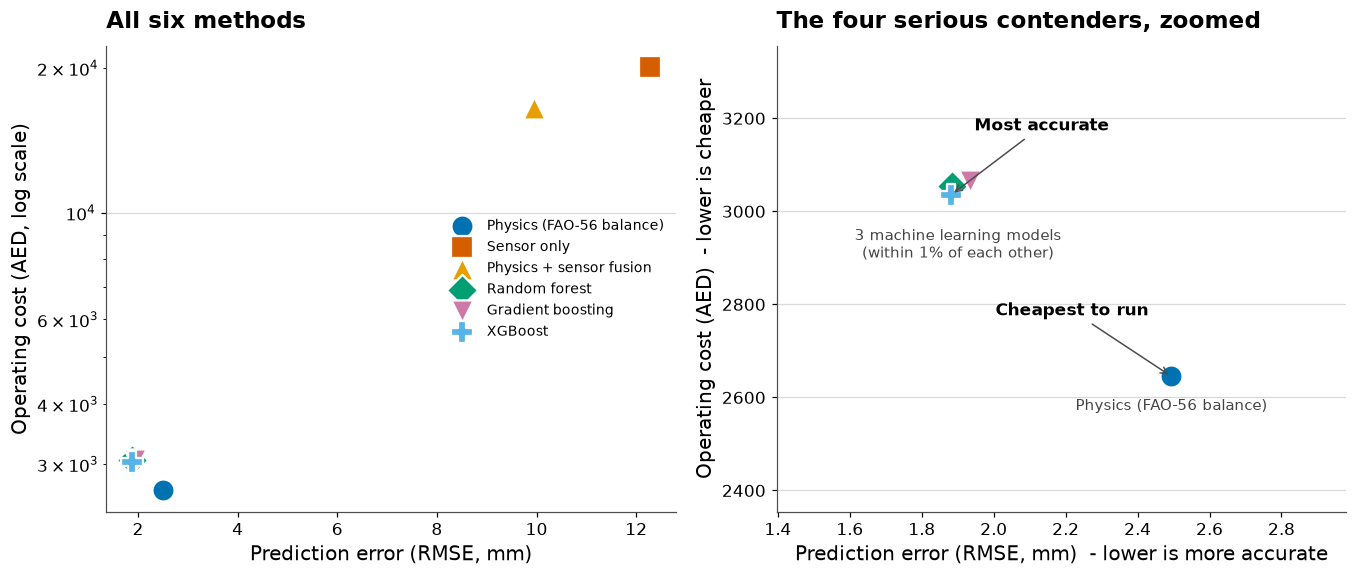

Lowest prediction error : XGBoost (RMSE 1.88 mm, cost 3,036 AED)
Lowest operating cost   : Physics (FAO-56 balance) (RMSE 2.49 mm, cost 2,645 AED)
Accuracy gap            : +0.61 mm
Cost gap                : +391 AED


In [3]:
best_rmse = min(results, key=lambda r: r.depletion_rmse)
best_cost = min(results, key=lambda r: r.total_cost)

# Two panels rather than one. The sensor-based methods are so much worse that
# on a single set of axes they compress the four serious contenders into an
# unreadable corner - and those four are the entire argument.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))

for ax in axes:
    for result in results:
        name = result.predictor_name
        ax.scatter(result.depletion_rmse, result.total_cost, s=210,
                   color=colour_for(name), marker=marker_for(name),
                   edgecolor="white", linewidth=1.5, zorder=3, label=name)

axes[0].set_yscale("log")
axes[0].set_xlabel("Prediction error (RMSE, mm)")
axes[0].set_ylabel("Operating cost (AED, log scale)")
axes[0].set_title("All six methods")
axes[0].legend(loc="center right", fontsize=9)

contenders = [r for r in results if r.total_cost < best_cost.total_cost * 2.5]
x_values = [r.depletion_rmse for r in contenders]
y_values = [r.total_cost for r in contenders]
pad_x = (max(x_values) - min(x_values)) * 0.55 + 0.15
pad_y = (max(y_values) - min(y_values)) * 0.55 + 60

axes[1].set_xlim(min(x_values) - pad_x, max(x_values) + pad_x)
axes[1].set_ylim(min(y_values) - pad_y, max(y_values) + pad_y)
axes[1].set_xlabel("Prediction error (RMSE, mm)  - lower is more accurate")
axes[1].set_ylabel("Operating cost (AED)  - lower is cheaper")
axes[1].set_title("The four serious contenders, zoomed")

axes[1].annotate("Most accurate", (best_rmse.depletion_rmse, best_rmse.total_cost),
                 xytext=(15, 42), textcoords="offset points", fontsize=11,
                 fontweight="bold", ha="left",
                 arrowprops=dict(arrowstyle="->", color="#4D4D4D"))
axes[1].annotate("Cheapest to run", (best_cost.depletion_rmse, best_cost.total_cost),
                 xytext=(-15, 40), textcoords="offset points", fontsize=11,
                 fontweight="bold", ha="right",
                 arrowprops=dict(arrowstyle="->", color="#4D4D4D"))

# The three supervised models sit almost exactly on top of one another, so
# they get one label between them rather than three overlapping ones. That is
# also the more honest presentation: the point is that they are
# indistinguishable, not that each deserves separate identification.
supervised = [r for r in contenders if not r.predictor_name.startswith("Physics (")]
physics = next(r for r in contenders if r.predictor_name.startswith("Physics ("))

axes[1].annotate(f"{len(supervised)} machine learning models\n(within 1% of each other)",
                 (float(np.mean([r.depletion_rmse for r in supervised])),
                  float(np.mean([r.total_cost for r in supervised]))),
                 xytext=(0, -46), textcoords="offset points",
                 ha="center", fontsize=9.5, color="#444444")
axes[1].annotate(physics.predictor_name,
                 (physics.depletion_rmse, physics.total_cost),
                 xytext=(0, -22), textcoords="offset points",
                 ha="center", fontsize=9.5, color="#444444")

plt.tight_layout()
plt.show()

print(f"Lowest prediction error : {best_rmse.predictor_name} "
      f"(RMSE {best_rmse.depletion_rmse:.2f} mm, cost {best_rmse.total_cost:,.0f} AED)")
print(f"Lowest operating cost   : {best_cost.predictor_name} "
      f"(RMSE {best_cost.depletion_rmse:.2f} mm, cost {best_cost.total_cost:,.0f} AED)")
print(f"Accuracy gap            : {best_cost.depletion_rmse - best_rmse.depletion_rmse:+.2f} mm")
print(f"Cost gap                : {best_rmse.total_cost - best_cost.total_cost:+,.0f} AED")


## The headline result

**The most accurate model is not the cheapest to operate.**

The machine learning models predict root-zone depletion more accurately than
the physics baseline does, and they still cost more to run. The reason is
visible in the water column of the table above: they err systematically toward
"drier than reality" and irrigate accordingly, applying a few hundred extra
millimetres over the season, most of which drains straight past the roots.

Crucially this is **not one model getting unlucky**. Random forest, gradient
boosting and XGBoost are three different learning algorithms - one that cannot
extrapolate beyond its training range and two that can. All three land on the
same side of the truth. Swapping the estimator does not fix it, because the
estimator was never what was wrong: fitting to squared error produces a model
optimized for a symmetric world, and this world is not symmetric.

Reporting "we trained a model and reached 1.9 mm RMSE" would have been true,
impressive-sounding, and would have cost the client money.


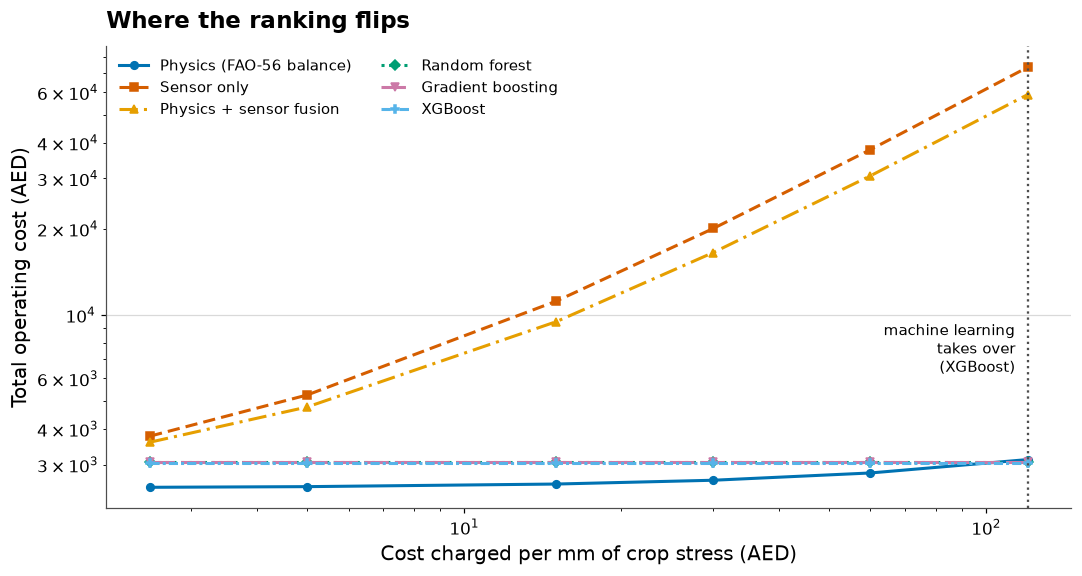

stress penalty    2.5 AED/mm  ->  cheapest: Physics (FAO-56 balance)
stress penalty    5.0 AED/mm  ->  cheapest: Physics (FAO-56 balance)
stress penalty   15.0 AED/mm  ->  cheapest: Physics (FAO-56 balance)
stress penalty   30.0 AED/mm  ->  cheapest: Physics (FAO-56 balance)
stress penalty   60.0 AED/mm  ->  cheapest: Physics (FAO-56 balance)
stress penalty  120.0 AED/mm  ->  cheapest: XGBoost


In [4]:
penalties = [2.5, 5.0, 15.0, 30.0, 60.0, 120.0]
curves: dict[str, list[float]] = {name: [] for name in names}

for penalty in penalties:
    scenario = run_comparison(crop, soil, root_depth_m=0.5, kc=0.85,
                              cost_model=CostModel(stress_cost_per_mm_deficit=penalty))
    for result in scenario:
        curves[result.predictor_name].append(result.total_cost)

fig, ax = plt.subplots(figsize=(10, 5.4))
for name, series in curves.items():
    ax.plot(penalties, series, color=colour_for(name), marker=marker_for(name),
            label=name)
    ax.lines[-1].set_dashes(dashes_for(name) if dashes_for(name)[0] else [])

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cost charged per mm of crop stress (AED)")
ax.set_ylabel("Total operating cost (AED)")
ax.set_title("Where the ranking flips")
ax.legend(ncol=2, fontsize=9.5)

# Two plain locals rather than an optional tuple. Subscripting a value that
# may be None makes every later line re-establish that it is not, and the
# positions of a bare tuple carry no meaning to a reader either.
crossover_penalty: float | None = None
crossover_winner = ""
for index, penalty in enumerate(penalties):
    winner = min(curves, key=lambda n: curves[n][index])
    if not winner.startswith("Physics ("):
        crossover_penalty, crossover_winner = penalty, winner
        break

if crossover_penalty is not None:
    ax.axvline(crossover_penalty, color="#4D4D4D", linestyle=":", linewidth=1.5)
    # Right-aligned and nudged left. The crossover is the last point on the
    # axis, so a centred label puts half its width outside the plot.
    ax.annotate(f"machine learning\ntakes over\n({crossover_winner})",
                (crossover_penalty, ax.get_ylim()[0] * 3),
                xytext=(-8, 0), textcoords="offset points",
                fontsize=10, ha="right")

plt.tight_layout()
plt.show()

for index, penalty in enumerate(penalties):
    winner = min(curves, key=lambda n: curves[n][index])
    print(f"stress penalty {penalty:6.1f} AED/mm  ->  cheapest: {winner}")


## When would machine learning be the right call?

Only when crop stress is catastrophically expensive.

At every ordinary cost ratio the 1998 water balance wins - with no training
data, no sensor, and no inference cost. Machine learning takes over only at the
far end, where stress is so ruinous that the models' systematic over-watering
becomes cheap insurance.

**That is a real answer, and a defensible recommendation.** It is also one a
client is unlikely to hear from a vendor selling models. The right response to
"should we use AI for this?" is sometimes no - and being able to show exactly
where the answer would change is more valuable than either a yes or a no.


In [5]:
from irrigation.decision.policy import decide
from irrigation.explain.advisor import explain_decision

for depletion, et0 in [(13.8, 8.4), (4.0, 5.2)]:
    decision = decide(predicted_depletion_mm=depletion, et0_forecast_mm=et0,
                      crop=crop, soil=soil, root_depth_m=0.5, kc=0.85)
    explanation = explain_decision(decision, et0_forecast_mm=et0,
                                   crop_name="turfgrass", soil_name="sand")
    print(explanation.render())
    print()


IRRIGATE 15.3 mm today (turfgrass, sand)
  Root zone is 13.8 mm depleted of 35.0 mm total available (39%). Tomorrow's reference ET is 8.4 mm/day, which would carry depletion past the readily available limit of 12.7 mm and reduce transpiration below potential.
  Grounded in:
    [raw_trigger] FAO-56 Ch. 8, Eq. 84
    [high_demand_adjustment] FAO-56 Ch. 8, Eq. 83
    [sandy_soil] FAO-56 Ch. 8, Table 19

HOLD - no irrigation today (turfgrass)
  Root zone is 4.0 mm depleted of 35.0 mm (11%), and tomorrow's reference ET of 5.2 mm/day keeps it within the 17.2 mm readily available limit. Applying water now would drain below the root zone rather than be stored.
  Grounded in:
    [raw_trigger] FAO-56 Ch. 8, Eq. 84
    [sandy_soil] FAO-56 Ch. 8, Table 19



## Explaining the decision

Every number above was computed by the physics layer before any text was
generated. The explanation layer only assembles them into sentences and
attaches the FAO-56 passage that justifies the rule being applied.

An optional language model (via Ollama) can rewrite this more fluently. When it
is enabled, **every number it emits is extracted and checked against the
supplied facts**, and any output containing a figure that was not provided is
discarded in favour of the deterministic text above. A model that invents a
plausible-looking application depth is the one failure mode that would actually
damage a client's turf, so it is blocked mechanically rather than discouraged
by prompt wording.

---

## Summary

| Question                               | Answer                                                            |
|----------------------------------------|-------------------------------------------------------------------|
| Which method is cheapest to run?       | The FAO-56 water balance, at every ordinary cost ratio            |
| Does machine learning predict better?  | Yes - and it still costs more                                     |
| Why?                                   | It errs toward "too dry", over-waters, and the excess drains away |
| Is that one bad model?                 | No - three different algorithms all do it                         |
| Should the client trust a bare sensor? | No - drift makes it roughly 8x more expensive                     |
| When would ML be right?                | Only where crop stress is catastrophically costly                 |
